<a href="https://colab.research.google.com/github/dewzpruth/genaiexps/blob/main/genai1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 147MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 36.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 90.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]


Starting training...
Epoch [1/10], Loss: 0.051181
Epoch [2/10], Loss: 0.024629
Epoch [3/10], Loss: 0.018375
Epoch [4/10], Loss: 0.015492
Epoch [5/10], Loss: 0.013515
Epoch [6/10], Loss: 0.012019
Epoch [7/10], Loss: 0.010983
Epoch [8/10], Loss: 0.010232
Epoch [9/10], Loss: 0.009628
Epoch [10/10], Loss: 0.009133
Training completed!

Visualizing Original vs Reconstructed Images (10 random samples)...


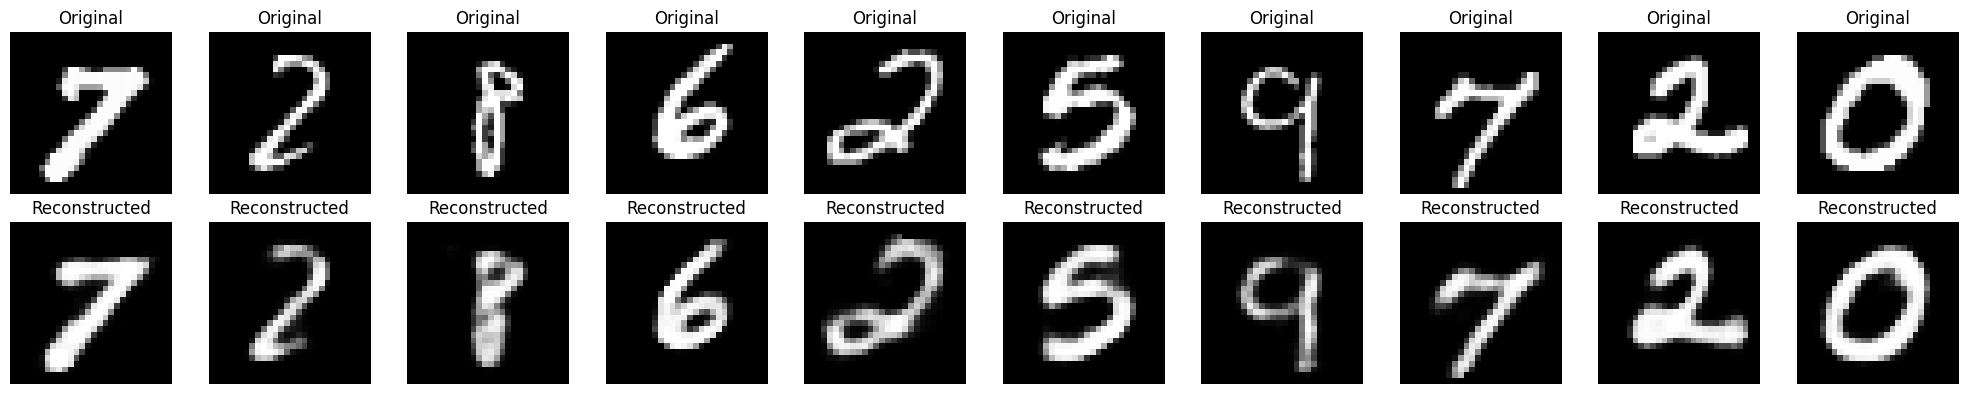

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
# Reproducibility for exact loss matching
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 128
learning_rate = 0.001
num_epochs = 10
latent_dim = 32
transform = transforms.Compose([transforms.ToTensor(),
 transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
class Autoencoder(nn.Module):
 def __init__(self):
  super(Autoencoder, self).__init__()
  self.encoder = nn.Sequential(
   nn.Linear(784, 256), nn.ReLU(),
   nn.Linear(256, 128), nn.ReLU(),
   nn.Linear(128, latent_dim))
  self.decoder = nn.Sequential(
   nn.Linear(latent_dim, 128), nn.ReLU(),
   nn.Linear(128, 256), nn.ReLU(),
   nn.Linear(256, 784), nn.Sigmoid())
 def forward(self, x):
  return self.decoder(self.encoder(x))
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print("Starting training...")
for epoch in range(num_epochs):
 total_loss = 0
 for data in train_loader:
  img = data[0].to(device)
  output = model(img)
  loss = criterion(output, img)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  total_loss += loss.item()
 print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.6f}')
print("Training completed!")
# === SHOW SAMPLE IMAGES (Original vs Reconstructed) ===
print("\nVisualizing Original vs Reconstructed Images (10 random samples)...")
model.eval()
with torch.no_grad():
 test_images, _ = next(iter(train_loader))
 test_images = test_images[:10].to(device)
 reconstructed = model(test_images)
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
 # Original
 orig = test_images[i].cpu().view(28, 28).numpy()
 axes[0, i].imshow(orig, cmap='gray')
 axes[0, i].axis('off')
 axes[0, i].set_title("Original")
 # Reconstructed
 recon = reconstructed[i].cpu().view(28, 28).numpy()
 axes[1, i].imshow(recon, cmap='gray')
 axes[1, i].axis('off')
 axes[1, i].set_title("Reconstructed")
plt.tight_layout()
plt.show()